In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import tensorflow as tf
from tqdm import tqdm
import torch
import torch.nn.functional as F
from tensorflow.keras.utils import to_categorical

2025-02-18 11:18:46.522880: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1739895526.534797 2918701 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739895526.538415 2918701 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-18 11:18:46.551534: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [19]:
data= pd.read_csv("/home/desabh/FER/fer+ck+augmentedfer.csv")

In [20]:
data.head()

,emotion,Usage,pixels
0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,Training,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,Training,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


In [7]:

data.shape

(75069, 3)

In [21]:
# Process the third column to convert pixel strings to arrays
data['pixels'] = data[' pixels'].apply(lambda x: np.array(x.split(), dtype=np.float32) / 255.0)
# Select the second column (index 1) as the splitter column
splitter_column = data.iloc[:, 1]

In [22]:
# Split the dataset based on the values in the second column
train_data = data[splitter_column == 'Training']
validation_data = data[splitter_column == 'PublicTest']
test_data = data[splitter_column == 'PrivateTest']

In [23]:

def preprocess_data(data):
    # Get the pixel data and convert to a list of arrays
    pixel_data = data['pixels'].tolist()

    # Check if all arrays have the expected length (2304 for a 48x48 image)
    expected_length = 48 * 48
    valid_pixel_data = [pixels for pixels in pixel_data if len(pixels) == expected_length]

    # Filter out data with incorrect shapes
    data = data[data['pixels'].apply(lambda x: len(x) == expected_length)]

    # Convert the valid pixel data to a numpy array and reshape
    images = np.array(valid_pixel_data).reshape(-1, 48, 48, 1)
    return images

# Preprocess the data using the updated function
X_train = preprocess_data(train_data)
X_validation = preprocess_data(validation_data)
X_test = preprocess_data(test_data)

y_train = to_categorical(train_data['emotion'], num_classes=7)
y_validation = to_categorical(validation_data['emotion'], num_classes=7)
y_test = to_categorical(test_data['emotion'], num_classes=7)

In [24]:
import numpy as np

# Get unique class indices from one-hot encoded labels
unique_classes = np.unique(y_test.argmax(axis=1))

# Create a dictionary mapping class index to one-hot encoded representation
class_mapping = {cls: np.eye(len(unique_classes))[cls] for cls in unique_classes}

# Print unique class names and their corresponding one-hot vectors
for cls, one_hot in class_mapping.items():
    print(f"Class: {cls}, One-Hot: {one_hot}")


Class: 0, One-Hot: [1. 0. 0. 0. 0. 0. 0.]
Class: 1, One-Hot: [0. 1. 0. 0. 0. 0. 0.]
Class: 2, One-Hot: [0. 0. 1. 0. 0. 0. 0.]
Class: 3, One-Hot: [0. 0. 0. 1. 0. 0. 0.]
Class: 4, One-Hot: [0. 0. 0. 0. 1. 0. 0.]
Class: 5, One-Hot: [0. 0. 0. 0. 0. 1. 0.]
Class: 6, One-Hot: [0. 0. 0. 0. 0. 0. 1.]


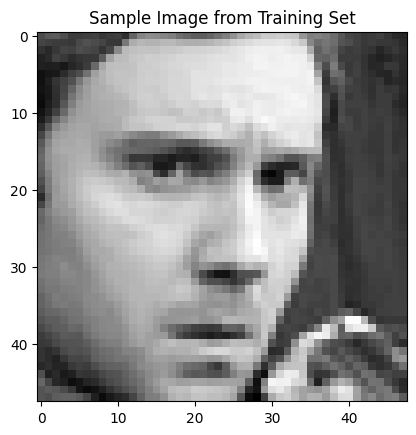

In [13]:

import matplotlib.pyplot as plt

# Assuming X_train is your preprocessed training data
# and you want to display the first image

# Display the first image from the training set
plt.imshow(X_train[0].reshape(48, 48), cmap='gray')
plt.title('Sample Image from Training Set')
plt.show()


In [14]:
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Define augmentation transformations
train_transforms = transforms.Compose([
    transforms.RandomRotation(degrees=30),  # Rotate by ±30 degrees
    transforms.RandomHorizontalFlip(),  # Flip image horizontally
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2)),  # Width & height shift
    transforms.RandomResizedCrop(size=48, scale=(0.8, 1.2)),  # Zoom
    transforms.ToTensor(),  # Convert to tensor
])




In [15]:
print(train_transforms)

Compose(
    RandomRotation(degrees=[-30.0, 30.0], interpolation=nearest, expand=False, fill=0)
    RandomHorizontalFlip(p=0.5)
    RandomAffine(degrees=[0.0, 0.0], translate=(0.2, 0.2))
    RandomResizedCrop(size=(48, 48), scale=(0.8, 1.2), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    ToTensor()
)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SEBlock(nn.Module):
    """Squeeze-and-Excitation Block with improved reduction ratio"""
    def __init__(self, in_channels, reduction=8):  # Stronger reduction
        super(SEBlock, self).__init__()
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(in_channels, in_channels // reduction)
        self.fc2 = nn.Linear(in_channels // reduction, in_channels)
        
    def forward(self, x):
        batch, channels, _, _ = x.shape
        out = self.global_avg_pool(x).view(batch, channels)
        out = F.relu(self.fc1(out))
        out = torch.sigmoid(self.fc2(out)).view(batch, channels, 1, 1)
        return x * out

class ResidualSEBlock(nn.Module):
    """Squeeze-and-Excitation Block with Residual Connection"""
    def __init__(self, in_channels, reduction=8):
        super(ResidualSEBlock, self).__init__()
        self.se = SEBlock(in_channels, reduction)
        self.bn = nn.BatchNorm2d(in_channels)
        
    def forward(self, x):
        residual = x
        out = self.se(x)
        out = self.bn(out)
        out += residual  # True residual connection
        return F.relu(out)

class ImprovedInceptionBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ImprovedInceptionBlock, self).__init__()
        branch_channels = out_channels // 4
        
        # 1x1 Conv (Pointwise)
        self.conv1x1 = nn.Conv2d(in_channels, branch_channels, kernel_size=1)
        self.bn1x1 = nn.BatchNorm2d(branch_channels)
        
        # 3x3 Conv with bottleneck
        reduced_channels = in_channels // 2
        self.conv3x3 = nn.Sequential(
            nn.Conv2d(in_channels, reduced_channels, kernel_size=1),  # Bottleneck
            nn.BatchNorm2d(reduced_channels),
            nn.ReLU(inplace=True),
            # Fixed depthwise separable convolution - each channel operates on itself
            nn.Conv2d(reduced_channels, reduced_channels, kernel_size=3, padding=1, groups=reduced_channels),
            nn.Conv2d(reduced_channels, branch_channels, kernel_size=1),  # Pointwise to change channels
            nn.BatchNorm2d(branch_channels)
        )
        
        # 5x5 Conv with bottleneck
        self.conv5x5 = nn.Sequential(
            nn.Conv2d(in_channels, reduced_channels, kernel_size=1),  # Bottleneck
            nn.BatchNorm2d(reduced_channels),
            nn.ReLU(inplace=True),
            # Fixed depthwise separable convolution
            nn.Conv2d(reduced_channels, reduced_channels, kernel_size=5, padding=2, groups=reduced_channels),
            nn.Conv2d(reduced_channels, branch_channels, kernel_size=1),  # Pointwise
            nn.BatchNorm2d(branch_channels)
        )
        
        # Spatial Pyramid Pooling branch
        self.pool_proj = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, branch_channels, kernel_size=1),
            nn.BatchNorm2d(branch_channels)
        )
        
        # Residual Squeeze-and-Excitation for Feature Enhancement
        self.res_se = ResidualSEBlock(out_channels)
        
    def forward(self, x):
        x1 = F.relu(self.bn1x1(self.conv1x1(x)))
        x2 = F.relu(self.conv3x3(x))
        x3 = F.relu(self.conv5x5(x))
        x4 = F.relu(self.pool_proj(x))
        
        # Concatenate along channel dimension
        out = torch.cat([x1, x2, x3, x4], dim=1)
        out = self.res_se(out)  # Apply Residual SE
        return out

class DeepCNN(nn.Module):
    def __init__(self, input_channels=1, num_classes=7):
        super(DeepCNN, self).__init__()
        
        # Initial Conv Layers
        self.stem = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        
        # First block
        self.block1 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Inception Blocks with proper residual connections
        self.inception1 = ImprovedInceptionBlock(128, 192)
        self.inception2 = ImprovedInceptionBlock(192, 256)
        
        # Transition layer with gradual reduction
        self.transition = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=1),  # 1x1 to reduce channels
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Deep feature extraction
        self.features = nn.Sequential(
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU(inplace=True),
            ResidualSEBlock(384),
            nn.Conv2d(384, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            ResidualSEBlock(512),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Global pooling to handle variable input sizes
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        # Classifier with dropout
        self.classifier = nn.Sequential(
            nn.Linear(512, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        # Stem and initial blocks
        x = self.stem(x)
        x = self.block1(x)
        
        # Inception blocks
        x = self.inception1(x)
        x = self.inception2(x)
        
        # Transition and deep feature extraction
        x = self.transition(x)
        x = self.features(x)
        
        # Global pooling (handles variable input size)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        
        # Classification
        x = self.classifier(x)
        
        return x

# Example usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DeepCNN(input_channels=1, num_classes=7).to(device)
print(model)

# Parameter count
param_count = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {param_count:,}")

DeepCNN(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (inception1): InceptionBlock(
    (conv1x1): Conv2d(128, 32, kernel_size=(1, 1), stride=(1, 1))
    (conv3x3): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv5x5): Conv2d(128, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (pool_proj): Sequential(
      (0): MaxPool2d(kernel_size=3, stride=1, padding=1, dilation=1, ceil_mode=False)
      (1): Conv2d(128, 32, kernel_size=(1, 1), stride=(1, 1))
    )
    (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (inception2): InceptionBlock(
    (conv1x1): Conv2d(128, 32, kernel_size=(1, 1), stride=(1, 1))
    (conv3x3): Conv2

In [61]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import numpy as np
from PIL import Image  # You were missing this import
from tqdm import tqdm

class EmotionDataset(Dataset):
    def __init__(self, images, labels, transforms=None):
        self.images = images
        self.labels = labels
        self.transforms = transforms
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        
        if self.transforms:
            # Convert NumPy array to PIL Image for transformations
            image = Image.fromarray((image.squeeze() * 255).astype(np.uint8))
            image = self.transforms(image)
        else:
            # For datasets without transforms, still need to convert to tensor
            image = torch.FloatTensor(image)
            
        return image, label

# Define augmentation transformations for training set
train_transforms = transforms.Compose([
    transforms.RandomRotation(degrees=30),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2)),
    transforms.RandomResizedCrop(size=48, scale=(0.8, 1.2)),
    transforms.ToTensor(),
])

# Define simple transforms for validation/test (just normalization)
val_transforms = transforms.Compose([
    transforms.ToTensor(),
])

# Create datasets with appropriate transforms
train_dataset = EmotionDataset(X_train, y_train, transforms=train_transforms)
validation_dataset = EmotionDataset(X_validation, y_validation, transforms=val_transforms)
test_dataset = EmotionDataset(X_test, y_test, transforms=val_transforms)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [48]:

from torchsummary import summary


summary(model, (1, 48, 48))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 48, 48]             320
       BatchNorm2d-2           [-1, 32, 48, 48]              64
              ReLU-3           [-1, 32, 48, 48]               0
            Conv2d-4           [-1, 64, 48, 48]          18,496
       BatchNorm2d-5           [-1, 64, 48, 48]             128
              ReLU-6           [-1, 64, 48, 48]               0
            Conv2d-7          [-1, 128, 48, 48]          73,856
       BatchNorm2d-8          [-1, 128, 48, 48]             256
              ReLU-9          [-1, 128, 48, 48]               0
        MaxPool2d-10          [-1, 128, 24, 24]               0
           Conv2d-11           [-1, 48, 24, 24]           6,192
      BatchNorm2d-12           [-1, 48, 24, 24]              96
           Conv2d-13           [-1, 64, 24, 24]           8,256
      BatchNorm2d-14           [-1, 64,

In [49]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [89]:
criterion = nn.CrossEntropyLoss()  # For multi-class classification with one-hot labels
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [90]:



# Function to train the model
def train(model, train_loader, optimizer, criterion, num_epochs=100):
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}", unit="batch"):
            # Move data to the device (GPU if available)
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels.float())  # Labels are one-hot encoded
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            _, true_labels = torch.max(labels, 1)  # Get the index of the true label
            total += labels.size(0)
            correct += (predicted == true_labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = correct / total
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

# Train the model
train(model, train_loader, optimizer, criterion, num_epochs=100)

Epoch 1/100: 100%|██████████| 1061/1061 [01:01<00:00, 17.16batch/s]


Epoch [1/100], Loss: 0.1516, Accuracy: 0.9479


Epoch 2/100: 100%|██████████| 1061/1061 [01:01<00:00, 17.14batch/s]


Epoch [2/100], Loss: 0.1497, Accuracy: 0.9490


Epoch 3/100: 100%|██████████| 1061/1061 [01:02<00:00, 17.11batch/s]


Epoch [3/100], Loss: 0.1476, Accuracy: 0.9490


Epoch 4/100: 100%|██████████| 1061/1061 [01:01<00:00, 17.11batch/s]


Epoch [4/100], Loss: 0.1483, Accuracy: 0.9485


Epoch 5/100:   8%|▊         | 90/1061 [00:05<00:57, 17.03batch/s]


KeyboardInterrupt: 

In [57]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            # Convert labels to both formats we need
            labels_onehot = labels.to(device)  # Keep one-hot for criterion
            labels_indices = torch.argmax(labels, dim=1).to(device)  # Convert to indices for accuracy
            
            # Get model predictions
            outputs = model(images)
            loss = criterion(outputs, labels_onehot)
            total_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels_indices).sum().item()
            total += labels.size(0)
    
    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total
    return avg_loss, accuracy

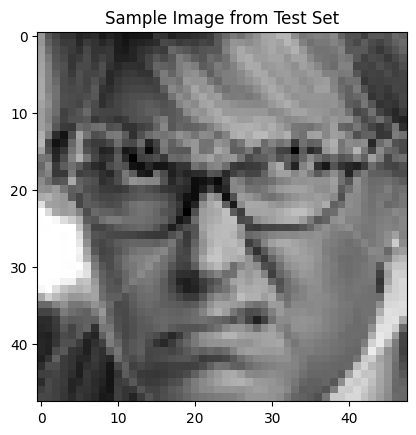

In [58]:
import matplotlib.pyplot as plt

# Assuming X_train is your preprocessed training data
# and you want to display the first image

# Display the first image from the training set
plt.imshow(X_test[0].reshape(48, 48), cmap='gray')
plt.title('Sample Image from Test Set')
plt.show()


In [59]:
print(y_test[0])

[1. 0. 0. 0. 0. 0. 0.]


In [62]:
test_loss, test_accuracy = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.3561, Test Accuracy: 0.8760


In [92]:
model_save_path = '/home/desabh/FER/v1_93.03.pth'

# Save the model's state_dict (weights)
torch.save(model.state_dict(), model_save_path)

In [55]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels.float())
            total_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            _, true_labels = torch.max(labels, 1)
            correct += (predicted == true_labels).sum().item()
            total += labels.size(0)
    
    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total
    return avg_loss, accuracy

def train(model, train_loader, val_loader, optimizer, criterion, num_epochs=100):
    # Lists to store metrics
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        # Training loop with progress bar
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}", unit="batch"):
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels.float())
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            _, true_labels = torch.max(labels, 1)
            total += labels.size(0)
            correct += (predicted == true_labels).sum().item()
        
        # Calculate training metrics
        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        
        # Validation phase
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        # Store metrics
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        
        # Print epoch results
        print(f"Epoch [{epoch + 1}/{num_epochs}]")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        print("-" * 50)
    
    # Return training history
    return {
        'train_losses': train_losses,
        'train_accuracies': train_accuracies,
        'val_losses': val_losses,
        'val_accuracies': val_accuracies
    }

# Train the model and get history
history = train(model, train_loader, validation_loader, optimizer, criterion, num_epochs=100)


Epoch 1/100:  12%|█▏        | 132/1061 [00:07<00:54, 17.18batch/s]


KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(12, 4))

# Plot losses
plt.subplot(1, 2, 1)
plt.plot(history['train_losses'], label='Train Loss')
plt.plot(history['val_losses'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot accuracies
plt.subplot(1, 2, 2)
plt.plot(history['train_accuracies'], label='Train Accuracy')
plt.plot(history['val_accuracies'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [74]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define path to the test folder
test_dir = "/home/desabh/.cache/kagglehub/datasets/msambare/fer2013/versions/1/test"

# Define transformations
test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Convert to grayscale if needed
    transforms.Resize((48, 48)),  # Ensure correct input size
    transforms.ToTensor(),
])

# Load test dataset
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transforms)

# Get original class-to-index mapping
original_class_order = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
new_class_order = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# Create mapping from original indices to new indices
old_to_new = [original_class_order.index(cls) for cls in new_class_order]

# Print class-to-index mapping
print("Class Mapping:", test_dataset.class_to_idx)

# Create DataLoader
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

def reorder_predictions(preds):
    """Reorders predictions from the original model output format to match the new dataset's label order."""
    return torch.tensor([old_to_new[p] for p in preds], device=preds.device)

Class Mapping: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [85]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Model's original output order (from training)
train_classes = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

# Desired evaluation order
desired_order = ['angry', 'disgust', 'fear', 'happy', 'surprise', 'neutral', 'sad']

# Mapping from model output to new order
output_mapping = [train_classes.index(cls) for cls in desired_order]
def reorder_predictions(preds, device):
    return torch.tensor([output_mapping[pred.item()] for pred in preds], device=device)

def evaluate(model, dataloader, criterion, device, class_names):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            
            # Model predictions
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            
            # Get predicted class
            _, predicted = torch.max(outputs, 1)
            
            # Reorder predictions to match desired order
            predicted = reorder_predictions(predicted, device)  # Pass device here
            
            # Store labels and predictions (move to CPU before converting to numpy)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    
    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total * 100
    print(f"Test Accuracy: {accuracy:.2f}%")
    
    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # Print classification report
    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=desired_order, digits=4))
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=desired_order, yticklabels=desired_order)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()
    
    return avg_loss, accuracy, cm

Test Accuracy: 93.31%

Classification Report:

              precision    recall  f1-score   support

       angry     0.9124    0.9238    0.9180       958
     disgust     0.9904    0.9279    0.9581       111
        fear     0.8790    0.8867    0.8828      1024
       happy     0.9841    0.9780    0.9811      1774
    surprise     0.9212    0.9384    0.9297      1233
     neutral     0.9000    0.9022    0.9011      1247
         sad     0.9788    0.9446    0.9614       831

    accuracy                         0.9331      7178
   macro avg     0.9380    0.9288    0.9332      7178
weighted avg     0.9336    0.9331    0.9333      7178



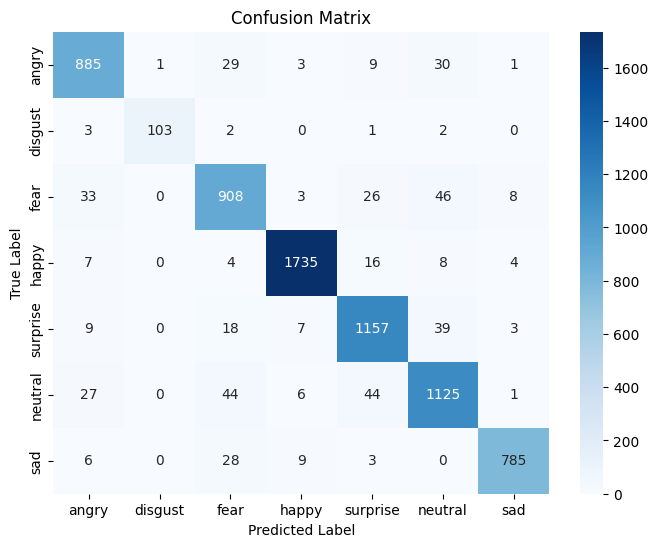

(6.616888571810802,
 93.31290052939536,
 array([[ 885,    1,   29,    3,    9,   30,    1],
        [   3,  103,    2,    0,    1,    2,    0],
        [  33,    0,  908,    3,   26,   46,    8],
        [   7,    0,    4, 1735,   16,    8,    4],
        [   9,    0,   18,    7, 1157,   39,    3],
        [  27,    0,   44,    6,   44, 1125,    1],
        [   6,    0,   28,    9,    3,    0,  785]]))

In [91]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = torch.nn.CrossEntropyLoss()
evaluate(model, test_loader, criterion, device, desired_order)